In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3, ResNet50V2, MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

2026-02-04 19:03:17.212597: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-04 19:03:17.244193: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-04 19:03:18.114073: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Check GPU is detected?
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for i, gpu in enumerate(gpus):
        # Get Specifications
        details = tf.config.experimental.get_device_details(gpu)
        gpu_name = details.get('device_name', 'Unknown GPU')
        compute_cap = details.get('compute_capability', 'Unknown')
        
        print(f"\n--- GPU #{i} ---")
        print(f"Name       : {gpu_name}")
        print(f"ID Path    : {gpu.name}")
        print(f"Compute Cap: {compute_cap}")
        
    # Built and Additional information
    print("\n--- Additional Information ---")
    print(f"TensorFlow Version          : {tf.__version__}")
    print(f"Built with CUDA             : {tf.test.is_built_with_cuda()}")
    print(f"Compute Capabilities Build  : {tf.sysconfig.get_build_info()['cuda_compute_capabilities']}")
else:
    print("❌ GPU Not Detected!")


--- GPU #0 ---
Name       : NVIDIA GeForce RTX 5060
ID Path    : /physical_device:GPU:0
Compute Cap: (12, 0)

--- Additional Information ---
TensorFlow Version          : 2.20.0-dev0+selfbuilt
Built with CUDA             : True
Compute Capabilities Build  : ['compute_120', 'compute_89', 'compute_86', 'compute_75', 'compute_61']


In [3]:
ROOT_DIR = "/media/DATA/.kaggle/autism-spectrum"
EPOCHS = 15
BATCH_SIZE = 32

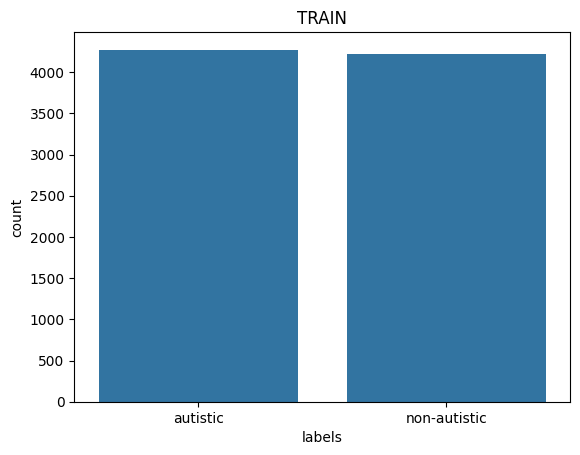

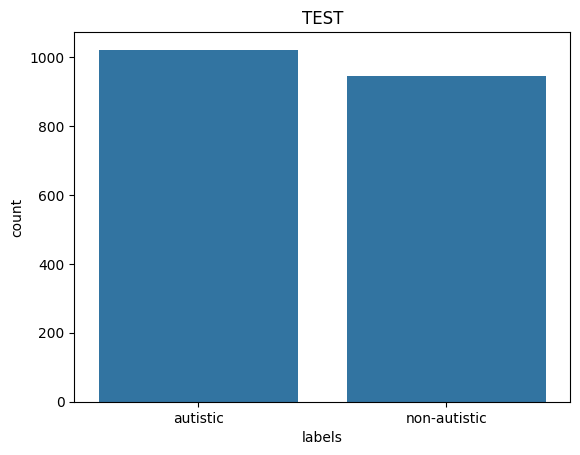

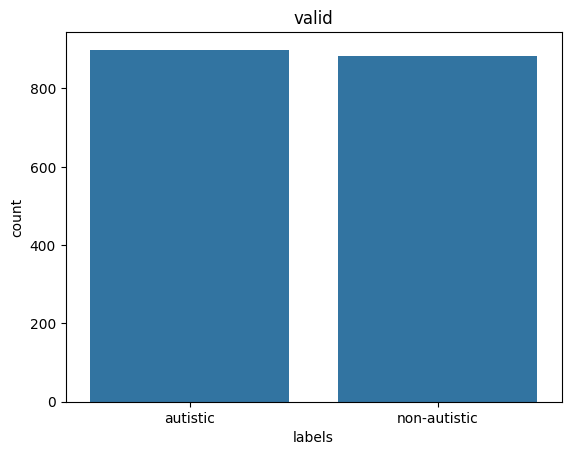

In [4]:
train_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/cleaned_train.csv")
test_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/cleaned_test.csv")
valid_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/cleaned_valid.csv")

sns.countplot(x='labels',data=train_df)
plt.title('TRAIN')
plt.show()
sns.countplot(x='labels',data=test_df)
plt.title('TEST')
plt.show()
sns.countplot(x='labels',data=valid_df)
plt.title('valid')
plt.show()

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
)
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    preprocessing_function=preprocess_input,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=(299, 299),       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
)

Found 8496 validated image filenames belonging to 2 classes.


In [6]:
test_datagen = ImageDataGenerator(rescale=1./255,)
test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    preprocessing_function=preprocess_input,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=(299, 299),       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
)

Found 1966 validated image filenames belonging to 2 classes.


In [7]:
valid_datagen = ImageDataGenerator(rescale=1./255,)
valid_gen = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    preprocessing_function=preprocess_input,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=(299, 299),       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
)

Found 1782 validated image filenames belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(
    include_top=False,        # exclude default FC layers
    weights="imagenet",       # load pretrained weights
    input_shape=(299, 299, 3) # MobileNetV2 expects 224x224 RGB images, but expected as 299x299 to test
)

base_model.trainable = False

/tmp/ipykernel_4951/103732096.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(
I0000 00:00:1770206599.763959    4951 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1424 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:01:00.0, compute capability: 12.0


In [14]:
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 150, 150,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 150, 150,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 150, 150,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 150, 150,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 150, 150,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 150, 150,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 150, 150,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 150, 150,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 150, 150,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 150, 150,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 150, 150,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 151, 151,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 75, 75,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 75, 75,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 75, 75,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 75, 75,    │      2,304 │ block_1_depthwis

 Total params: 2,914,369 (11.12 MB)

 Trainable params: 656,385 (2.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",   # or sparse_categorical_crossentropy
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor='accuracy',   # metric to watch (default: val_loss)
    patience=6,           # epochs with no improvement before stopping
    restore_best_weights=True
)

In [11]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    callbacks=[early_stop],
    epochs=EPOCHS
)

Epoch 1/15


2026-02-04 19:03:22.684746: I external/local_xla/xla/service/service.cc:153] XLA service 0x7ff410014040 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-04 19:03:22.684764: I external/local_xla/xla/service/service.cc:161]   StreamExecutor device (0): NVIDIA GeForce RTX 5060, Compute Capability 12.0
2026-02-04 19:03:22.748906: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770206603.151387    5649 cuda_dnn.cc:529] Loaded cuDNN version 91701
2026-02-04 19:03:23.891969: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1659', 592 bytes spill stores, 592 bytes spill loads

2026-02-04 19:03:24.695406: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optima

114/266 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.6486 - loss: 0.6736

2026-02-04 19:03:39.453781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-04 19:03:39.535561: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6848 - loss: 0.6116

2026-02-04 19:03:54.448585: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1160', 592 bytes spill stores, 592 bytes spill loads

2026-02-04 19:03:54.961833: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-04 19:03:55.051683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-04 19:03:55.769660: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-04 19:03:55.876190: E external/local_xla/xla/

266/266 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.7248 - loss: 0.5442 - val_accuracy: 0.7845 - val_loss: 0.4612
Epoch 2/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.7891 - loss: 0.4469 - val_accuracy: 0.7873 - val_loss: 0.4472
Epoch 3/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.8126 - loss: 0.4093 - val_accuracy: 0.8114 - val_loss: 0.4121
Epoch 4/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.8278 - loss: 0.3723 - val_accuracy: 0.8356 - val_loss: 0.3679
Epoch 5/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.8464 - loss: 0.3401 - val_accuracy: 0.8311 - val_loss: 0.3825
Epoch 6/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.8648 - loss: 0.3132 - val_accuracy: 0.8648 - val_loss: 0.3189
Epoch 7/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.8790 - loss: 0.2838 - val_accuracy: 0.8721 - val_loss: 0.3014
Epoch 8/15
266/266 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.8892 - loss: 0.2603 - val_accura

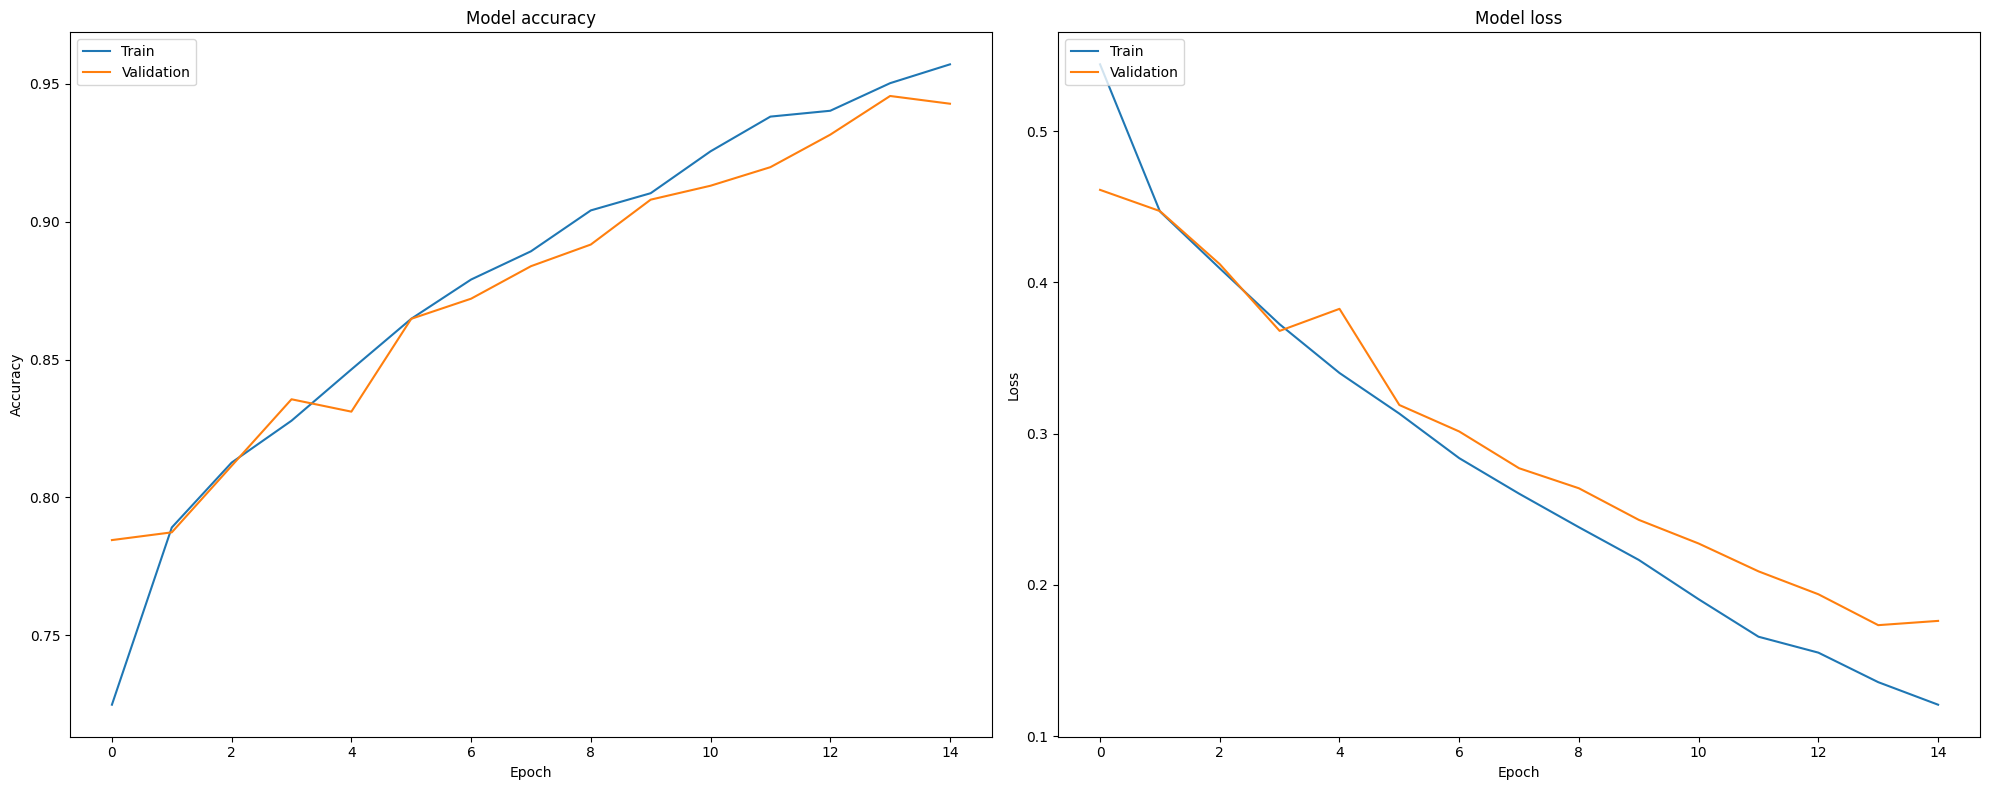

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(20, 8))

# Plot training accuracy
axs[0].plot(history.history['accuracy'])
axs[0].plot(history.history['val_accuracy'])
axs[0].set_title('Model accuracy')
axs[0].set_ylabel('Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].legend(['Train', 'Validation'], loc='upper left')

# Plot training loss
axs[1].plot(history.history['loss'])
axs[1].plot(history.history['val_loss'])
axs[1].set_title('Model loss')
axs[1].set_ylabel('Loss')
axs[1].set_xlabel('Epoch')
axs[1].legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [13]:
model.evaluate(test_gen)

61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9362 - loss: 0.1772

2026-02-04 19:06:53.100982: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-04 19:06:53.183012: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.9420 - loss: 0.1649


[0.16487281024456024, 0.942014217376709]